In [1]:
from games.mp import MP
from agents.regretmatching import RegretMatching
from agents.fictitiousplay import FictitiousPlay
from agents.random_agent import RandomAgent
from agents.iql import IndependentQLearning
from agents.jal_am import JointActionLearningAM
import matplotlib.pyplot as plt
import numpy as np

## Matching Pennies

Juego de **suma cero** con 2 agentes y 2 acciones: **H** (cara) y **T** (cruz).

Matrices de utilidades (filas = `agent_0`, columnas = `agent_1`):

|            | **H**     | **T**     |
|------------|-----------|-----------|
| **H**      | (+1, −1)  | (−1, +1)  |
| **T**      | (−1, +1)  | (+1, −1)  |

> Cada celda muestra `(u_0, u_1)`. Al ser un juego de suma cero, siempre `u_0 + u_1 = 0`.

**Estrategias dominantes puras:** ningún jugador tiene una estrategia que sea siempre mejor independientemente de lo que haga el oponente.
- `agent_0` prefiere **H** si `agent_1` juega H, pero prefiere **T** si `agent_1` juega T → no hay dominancia.
- `agent_1` prefiere **T** si `agent_0` juega H, pero prefiere **H** si `agent_0` juega T → no hay dominancia.

Analizando la matriz, se puede ver que no hay estrategias dominantes puras entre los agentes.


# Inicialización del juego


In [2]:
g = MP()

In [3]:
g.reset()

In [4]:
g.agents

['agent_0', 'agent_1']

## Funciones utilitarias

In [5]:
def play_game(game, agents, n_rounds=10000):
    """Reinicia el juego, ejecuta n_rounds rondas y retorna políticas y conteo de acciones."""
    game.reset()
    action_counts = {a: np.zeros(game._num_actions, dtype=int) for a in game.agents}
    for _ in range(n_rounds):
        actions = {a: agents[a].action() for a in game.agents}
        for a in game.agents:
            action_counts[a][actions[a]] += 1
        game.step(actions)
    policies = {a: agents[a].policy() for a in game.agents}
    return policies, action_counts


def plot_action_histogram(action_counts, game, title=''):
    """Histograma de acciones seleccionadas por cada agente durante el juego."""
    moves = game._moves
    colors = ['#e74c3c', '#3498db']
    fig, axes = plt.subplots(1, len(game.agents), figsize=(6 * len(game.agents), 3), sharey=True)
    for ax, agent in zip(axes, game.agents):
        counts = action_counts[agent]
        bars = ax.bar(moves, counts, color=colors[:len(moves)])
        ax.bar_label(bars, fmt='%d')
        ax.set_title(agent)
        ax.set_xlabel('Acción')
        ax.set_ylabel('Veces seleccionada')
        ax.set_ylim(0, max(counts) * 1.15)
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


def track_convergence(game, agents, checkpoints):
    """Registra policy()[0] en cada checkpoint. Retorna dict de historiales."""
    game.reset()
    history = {a: [] for a in game.agents}
    step = 0
    for cp in checkpoints:
        for _ in range(cp - step):
            actions = {a: agents[a].action() for a in game.agents}
            game.step(actions)
        step = cp
        for a in game.agents:
            history[a].append(agents[a].policy()[0])
    return history


def plot_convergence(history, checkpoints, title, nash_eq=0.5, action_label='H'):
    """Grafica la convergencia de las políticas hacia el equilibrio de Nash."""
    fig, ax = plt.subplots(figsize=(8, 4))
    for agent, values in history.items():
        ax.plot(checkpoints, values, marker='o', label=agent)
    ax.axhline(nash_eq, color='gray', linestyle='--', label=f'Nash equilibrium ({nash_eq})')
    ax.set_xscale('log')
    ax.set_xlabel('Rondas (escala log)')
    ax.set_ylabel(f'P(jugar {action_label})')
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## Experimentos: política final aprendida

### Regret Matching vs Regret Matching

In [6]:
agents = {a: RegretMatching(game=g, agent=a) for a in g.agents}
policies, action_counts = play_game(g, agents)
policies

{'agent_0': array([0.49351734, 0.50648266]),
 'agent_1': array([0.50760387, 0.49239613])}

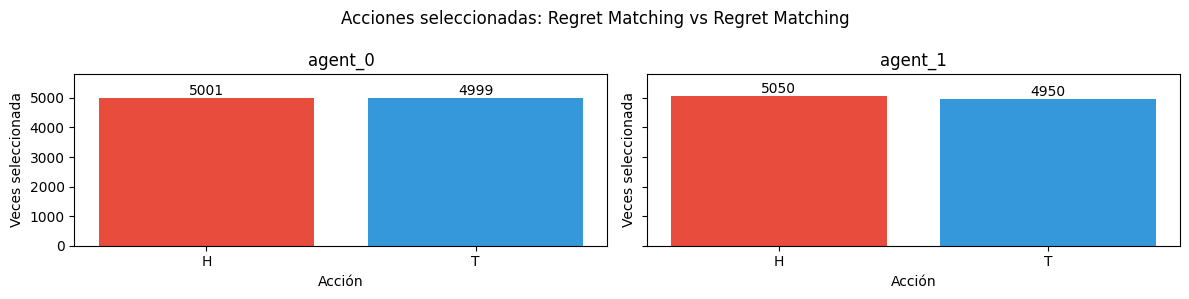

In [7]:
plot_action_histogram(action_counts, g, 'Acciones seleccionadas: Regret Matching vs Regret Matching')

### Regret Matching vs Random Agent

In [8]:
agents = {'agent_0': RegretMatching(game=g, agent='agent_0'), 'agent_1': RandomAgent(game=g, agent='agent_1')}
policies, action_counts = play_game(g, agents)
policies

{'agent_0': array([0.04065067, 0.95934933]), 'agent_1': array([0.5, 0.5])}

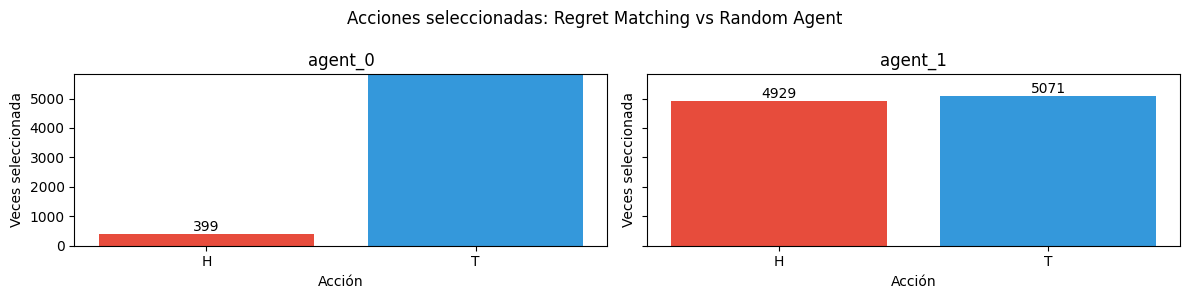

In [9]:
plot_action_histogram(action_counts, g, 'Acciones seleccionadas: Regret Matching vs Random Agent')

### Fictitious Play vs Fictitious Play

In [10]:
agents = {a: FictitiousPlay(game=g, agent=a) for a in g.agents}
policies, action_counts = play_game(g, agents)
policies

{'agent_0': array([0.50024963, 0.49975037]),
 'agent_1': array([0.50714357, 0.49285643])}

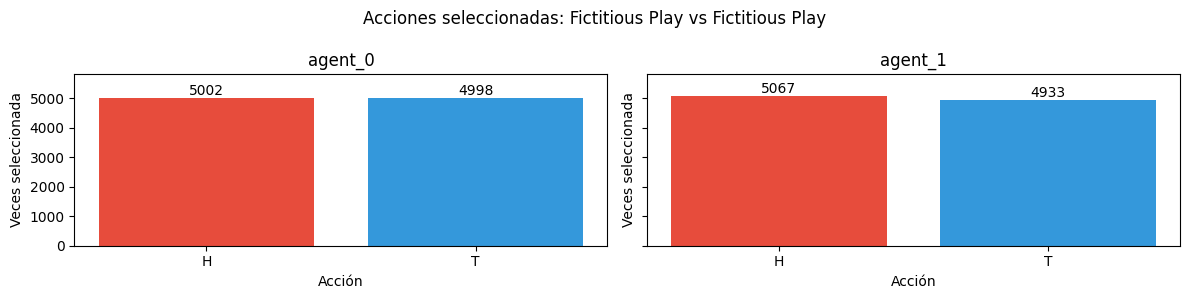

In [11]:
plot_action_histogram(action_counts, g, 'Acciones seleccionadas: Fictitious Play vs Fictitious Play')

### Fictitious Play vs Random Agent

In [12]:
agents = {'agent_0': FictitiousPlay(game=g, agent='agent_0'), 'agent_1': RandomAgent(game=g, agent='agent_1')}
policies, action_counts = play_game(g, agents)
policies

{'agent_0': array([0.99240911, 0.00759089]), 'agent_1': array([0.5, 0.5])}

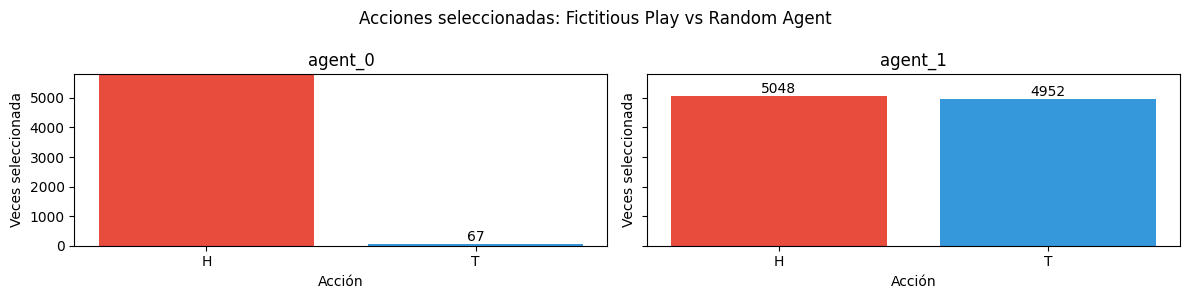

In [13]:
plot_action_histogram(action_counts, g, 'Acciones seleccionadas: Fictitious Play vs Random Agent')

### IQL vs Random Agent

In [14]:
agents = {'agent_0': IndependentQLearning(game=g, agent='agent_0'), 'agent_1': RandomAgent(game=g, agent='agent_1')}
policies, action_counts = play_game(g, agents)
policies

{'agent_0': array([0.79539945, 0.20460055]), 'agent_1': array([0.5, 0.5])}

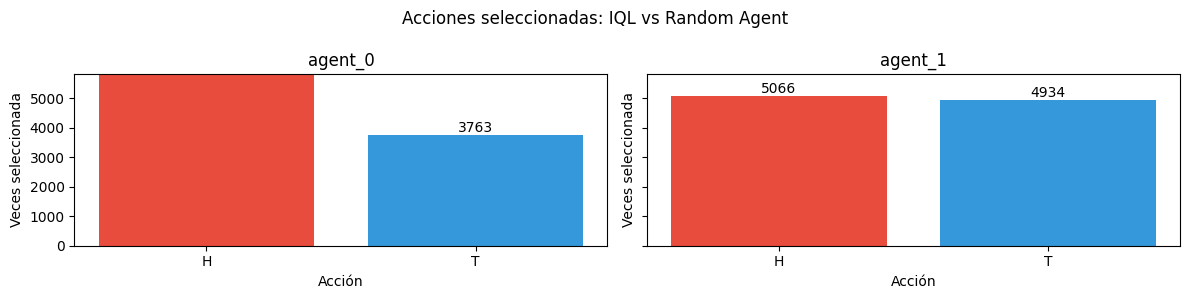

In [15]:
plot_action_histogram(action_counts, g, 'Acciones seleccionadas: IQL vs Random Agent')

### IQL vs IQL

In [16]:
agents = {a: IndependentQLearning(game=g, agent=a) for a in g.agents}
policies, action_counts = play_game(g, agents)
policies

{'agent_0': array([0.1386736, 0.8613264]),
 'agent_1': array([0.42258501, 0.57741499])}

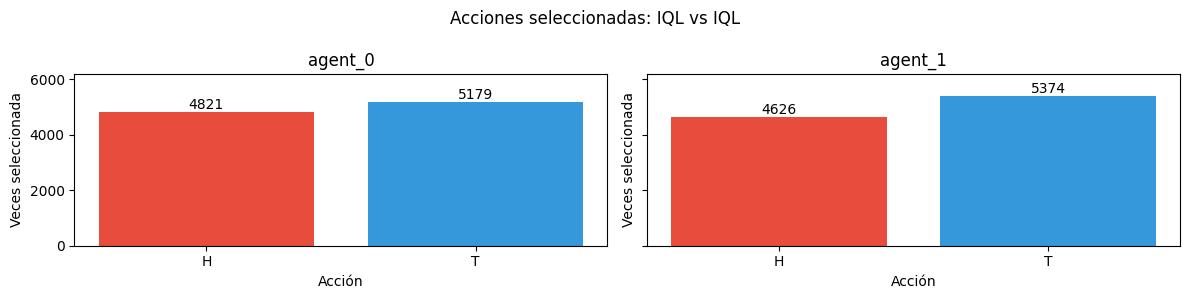

In [17]:
plot_action_histogram(action_counts, g, 'Acciones seleccionadas: IQL vs IQL')

### IQL vs Joint Action Learning AM

In [18]:
agents = {'agent_0': IndependentQLearning(game=g, agent='agent_0'), 'agent_1': JointActionLearningAM(game=g, agent='agent_1')}
policies, action_counts = play_game(g, agents)
policies

{'agent_0': array([0.83364647, 0.16635353]),
 'agent_1': array([0.50295232, 0.49704768])}

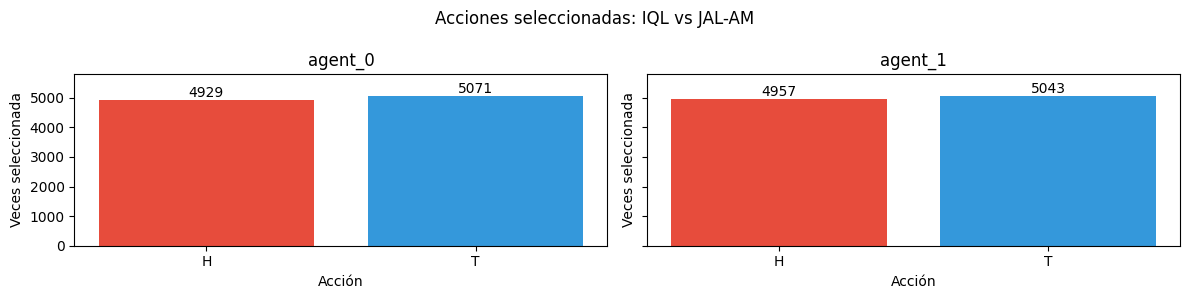

In [19]:
plot_action_histogram(action_counts, g, 'Acciones seleccionadas: IQL vs JAL-AM')

### Joint Action Learning AM vs Joint Action Learning AM

In [20]:
agents = {a: JointActionLearningAM(game=g, agent=a) for a in g.agents}
policies, action_counts = play_game(g, agents)
policies

{'agent_0': array([0.79287134, 0.20712866]),
 'agent_1': array([0.83086446, 0.16913554])}

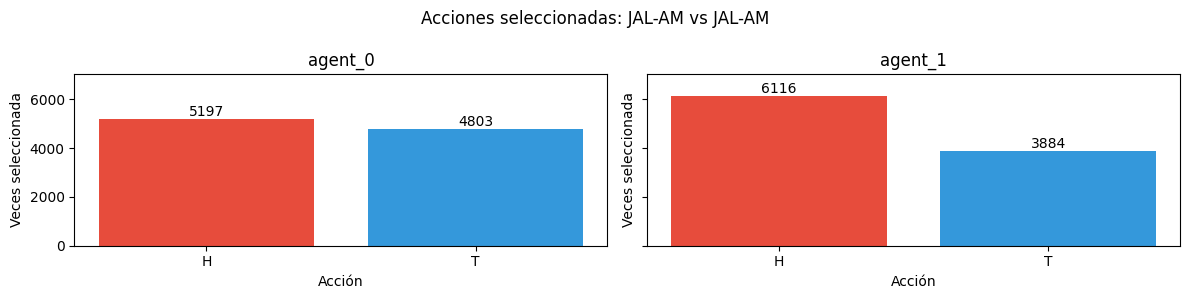

In [21]:
plot_action_histogram(action_counts, g, 'Acciones seleccionadas: JAL-AM vs JAL-AM')

## Análisis de Convergencia hacia el Equilibrio de Nash

Se registra la probabilidad de jugar **H** de cada agente a lo largo del tiempo (checkpoints en escala log) para visualizar la convergencia al equilibrio de Nash **[0.5, 0.5]** en estrategias mixtas. <br>
Vale aclarar que en no hay Nash puro, ya que no hay escenarios en donde ambos agentes estén jugando best responses mutuas.

In [22]:
checkpoints = [10, 50, 100, 500, 1000, 5000, 10000]

### Regret Matching vs Regret Matching

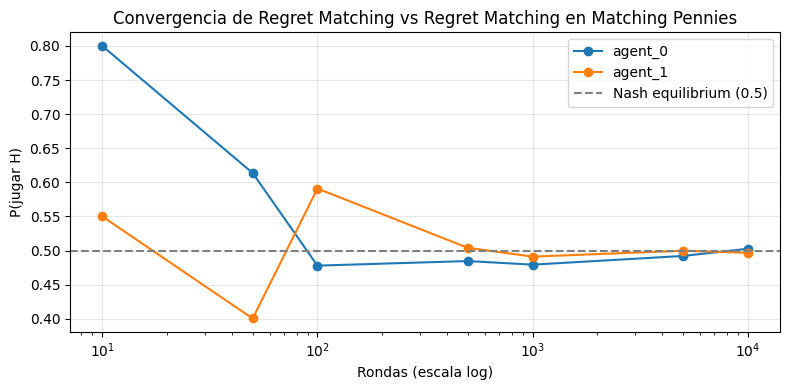

In [23]:
agents = {a: RegretMatching(game=g, agent=a) for a in g.agents}
history = track_convergence(g, agents, checkpoints)
plot_convergence(history, checkpoints, 'Convergencia de Regret Matching vs Regret Matching en Matching Pennies')

### Regret Matching vs Random Agent

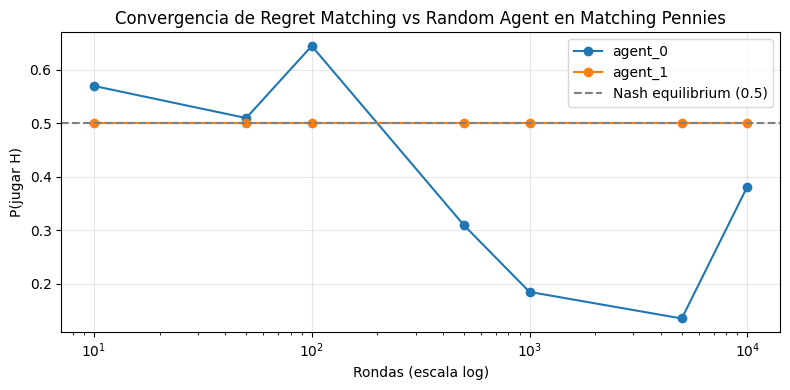

In [24]:
agents = {'agent_0': RegretMatching(game=g, agent='agent_0'), 'agent_1': RandomAgent(game=g, agent='agent_1')}
history = track_convergence(g, agents, checkpoints)
plot_convergence(history, checkpoints, 'Convergencia de Regret Matching vs Random Agent en Matching Pennies')

### Fictitious Play vs Fictitious Play

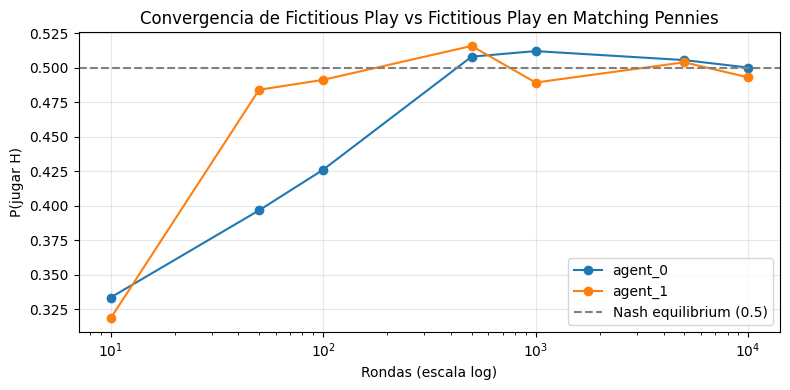

In [25]:
agents = {a: FictitiousPlay(game=g, agent=a) for a in g.agents}
history = track_convergence(g, agents, checkpoints)
plot_convergence(history, checkpoints, 'Convergencia de Fictitious Play vs Fictitious Play en Matching Pennies')

### Fictitious Play vs Random Agent

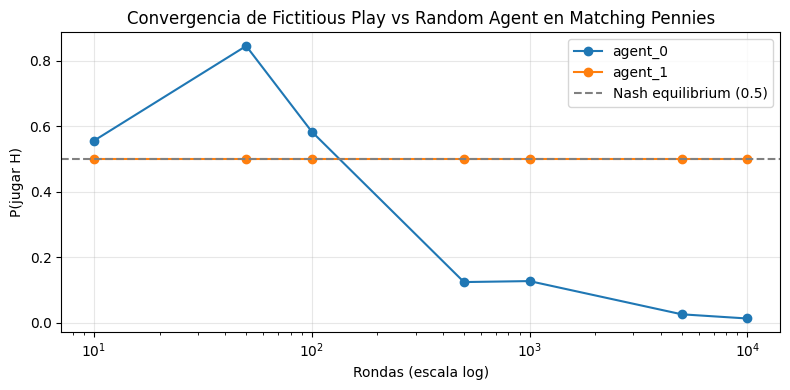

In [26]:
agents = {'agent_0': FictitiousPlay(game=g, agent='agent_0'), 'agent_1': RandomAgent(game=g, agent='agent_1')}
history = track_convergence(g, agents, checkpoints)
plot_convergence(history, checkpoints, 'Convergencia de Fictitious Play vs Random Agent en Matching Pennies')

### Fictitious Play vs Regret Matching

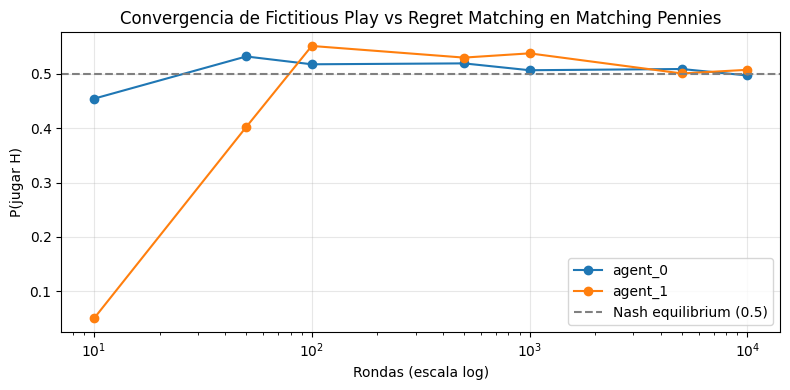

In [27]:
agents = {'agent_0': FictitiousPlay(game=g, agent='agent_0'), 'agent_1': RegretMatching(game=g, agent='agent_1')}
history = track_convergence(g, agents, checkpoints)
plot_convergence(history, checkpoints, 'Convergencia de Fictitious Play vs Regret Matching en Matching Pennies')

### IQL vs Random Agent

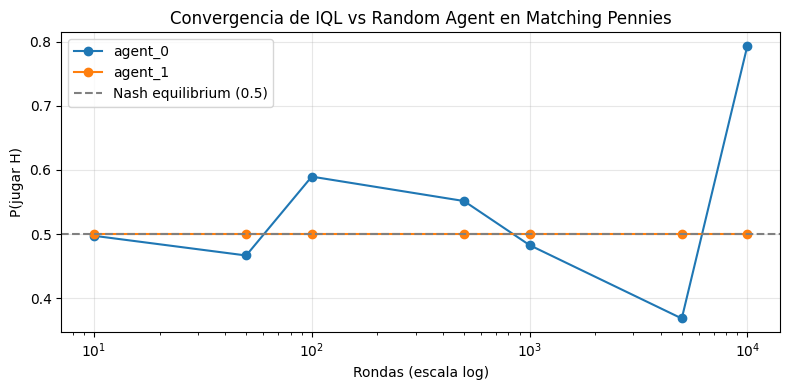

In [28]:
agents = {'agent_0': IndependentQLearning(game=g, agent='agent_0'), 'agent_1': RandomAgent(game=g, agent='agent_1')}
history = track_convergence(g, agents, checkpoints)
plot_convergence(history, checkpoints, 'Convergencia de IQL vs Random Agent en Matching Pennies')

### IQL vs IQL

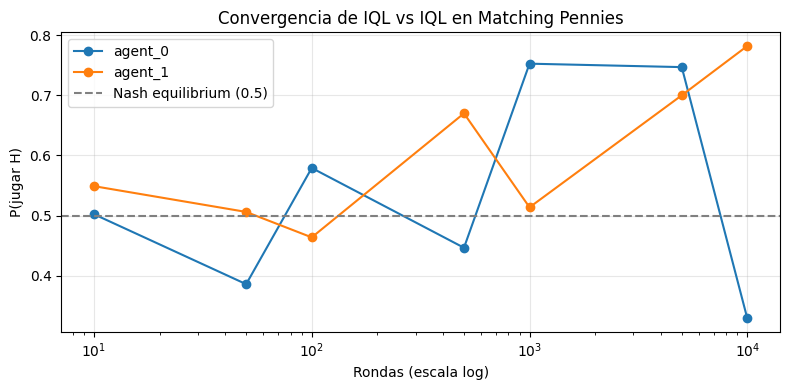

In [29]:
agents = {a: IndependentQLearning(game=g, agent=a) for a in g.agents}
history = track_convergence(g, agents, checkpoints)
plot_convergence(history, checkpoints, 'Convergencia de IQL vs IQL en Matching Pennies')

### IQL vs Joint Action Learning AM

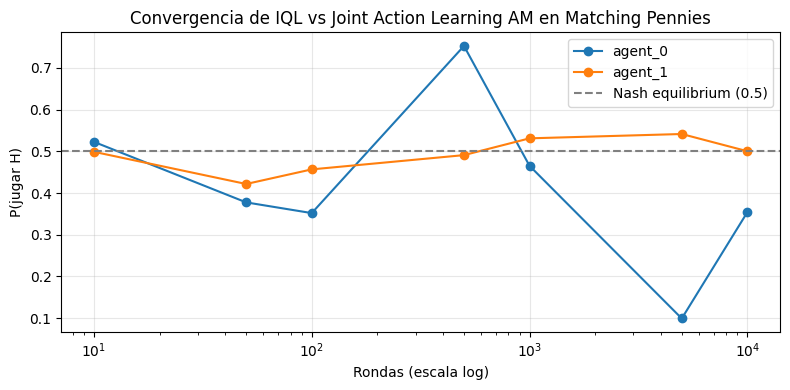

In [30]:
agents = {'agent_0': IndependentQLearning(game=g, agent='agent_0'), 'agent_1': JointActionLearningAM(game=g, agent='agent_1')}
history = track_convergence(g, agents, checkpoints)
plot_convergence(history, checkpoints, 'Convergencia de IQL vs Joint Action Learning AM en Matching Pennies')

### Joint Action Learning AM vs Joint Action Learning AM

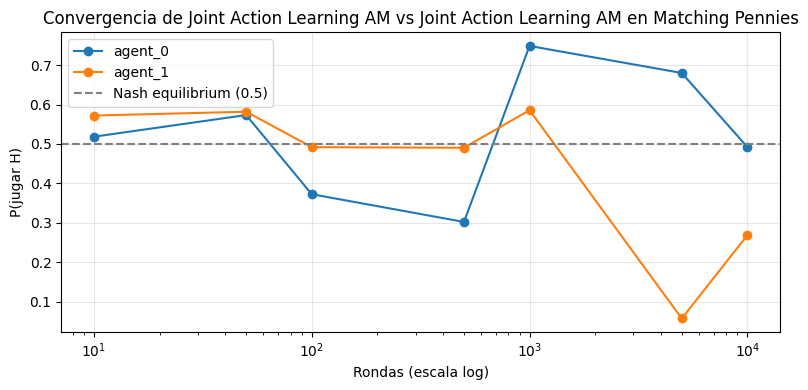

In [31]:
agents = {a: JointActionLearningAM(game=g, agent=a) for a in g.agents}
history = track_convergence(g, agents, checkpoints)
plot_convergence(history, checkpoints, 'Convergencia de Joint Action Learning AM vs Joint Action Learning AM en Matching Pennies')

## Análisis de Rewards (multi-seed con IC)

A continuación se extiende el análisis utilizando múltiples semillas (`N_SEEDS = 10`) y `N_EPISODES = 10.000` episodios por semilla, registrando rewards y políticas a lo largo del tiempo. Para cada matchup se muestran tres gráficas:

1. **Reward promedio** con banda de confianza (±1 desv. estándar).
2. **Distancia L1 al EN** $\|\pi - \pi^*\|_1$ con IC.
3. **P(H) actual vs. promedio acumulado** (seed 0), mostrando convergencia a $0.5$.

El Equilibrio de Nash en Matching Pennies es la estrategia mixta uniforme $\pi^* = (0.5, 0.5)$ para ambos jugadores, con reward esperado **0** en el EN.

In [32]:

import os
from utils.experiment import run_experiment, run_experiment_and_plot
from utils.io import save_results
from utils.plotting import plot_with_ci, smooth
from utils.metrics import dist_to_ne
from utils.constants import COLORS, IQL_KWARGS, JALAM_KWARGS

N_EPISODES = 10_000
N_SEEDS    = 10
NE_MP      = np.array([0.5, 0.5])
os.makedirs('results/MP', exist_ok=True)
os.makedirs('figures/MP', exist_ok=True)


#### RM vs RM

Saved → results/MP/RM_vs_RM/results.json


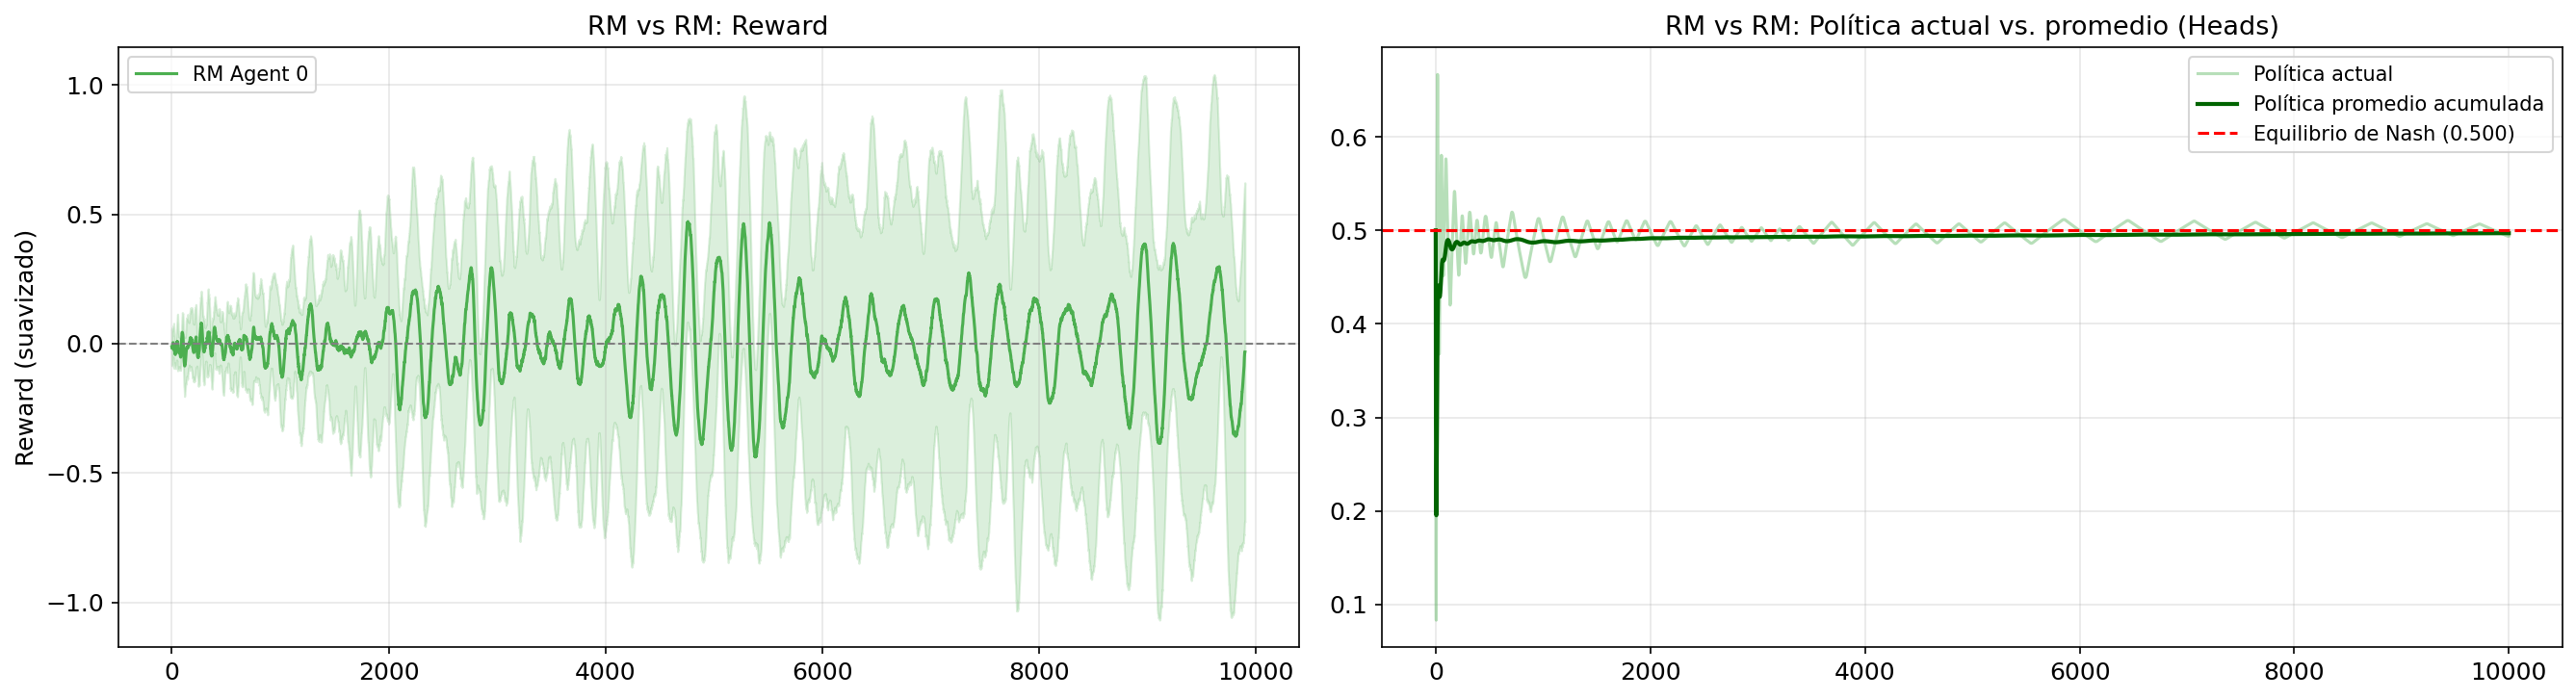

Política final FP (promedio sobre seeds):
  Agent 0: [0.495 0.505]
  Agent 1: [0.501 0.499]
  Equilibrio de Nash: [0.5 0.5]


In [33]:

rewards_rm, pol0_rm, pol1_rm = run_experiment_and_plot(
    MP, RegretMatching, RegretMatching,
    NE=NE_MP, color=COLORS['RM'],
    game_name='MP', experiment_name='RM_vs_RM',
    agent0_label='RM', agent1_label='RM',
    action_label='Heads', action_idx=0,
    n_episodes=N_EPISODES, n_seeds=N_SEEDS,
)


#### FP vs FP

Saved → results/MP/FP_vs_FP/results.json


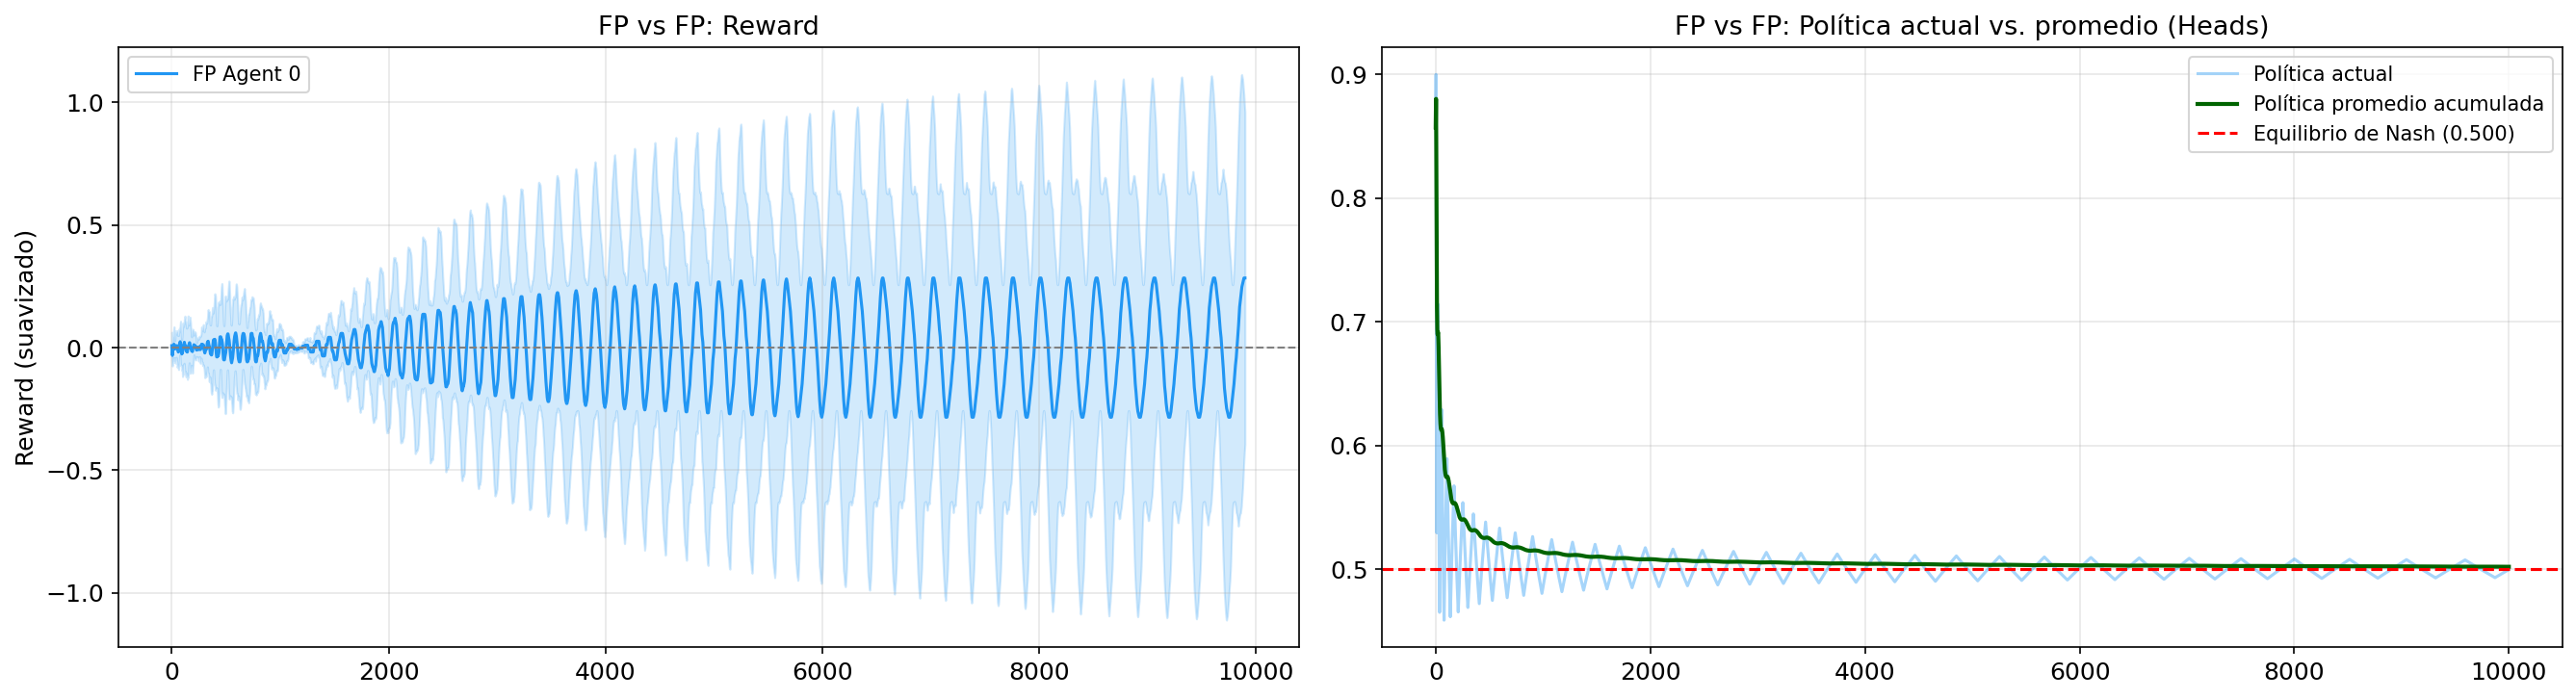

Política final FP (promedio sobre seeds):
  Agent 0: [0.501 0.499]
  Agent 1: [0.5 0.5]
  Equilibrio de Nash: [0.5 0.5]


In [34]:

rewards_fp, pol0_fp, pol1_fp = run_experiment_and_plot(
    MP, FictitiousPlay, FictitiousPlay,
    NE=NE_MP, color=COLORS['FP'],
    game_name='MP', experiment_name='FP_vs_FP',
    agent0_label='FP', agent1_label='FP',
    action_label='Heads', action_idx=0,
    n_episodes=N_EPISODES, n_seeds=N_SEEDS,
)


#### IQL vs IQL

Saved → results/MP/IQL_vs_IQL/results.json


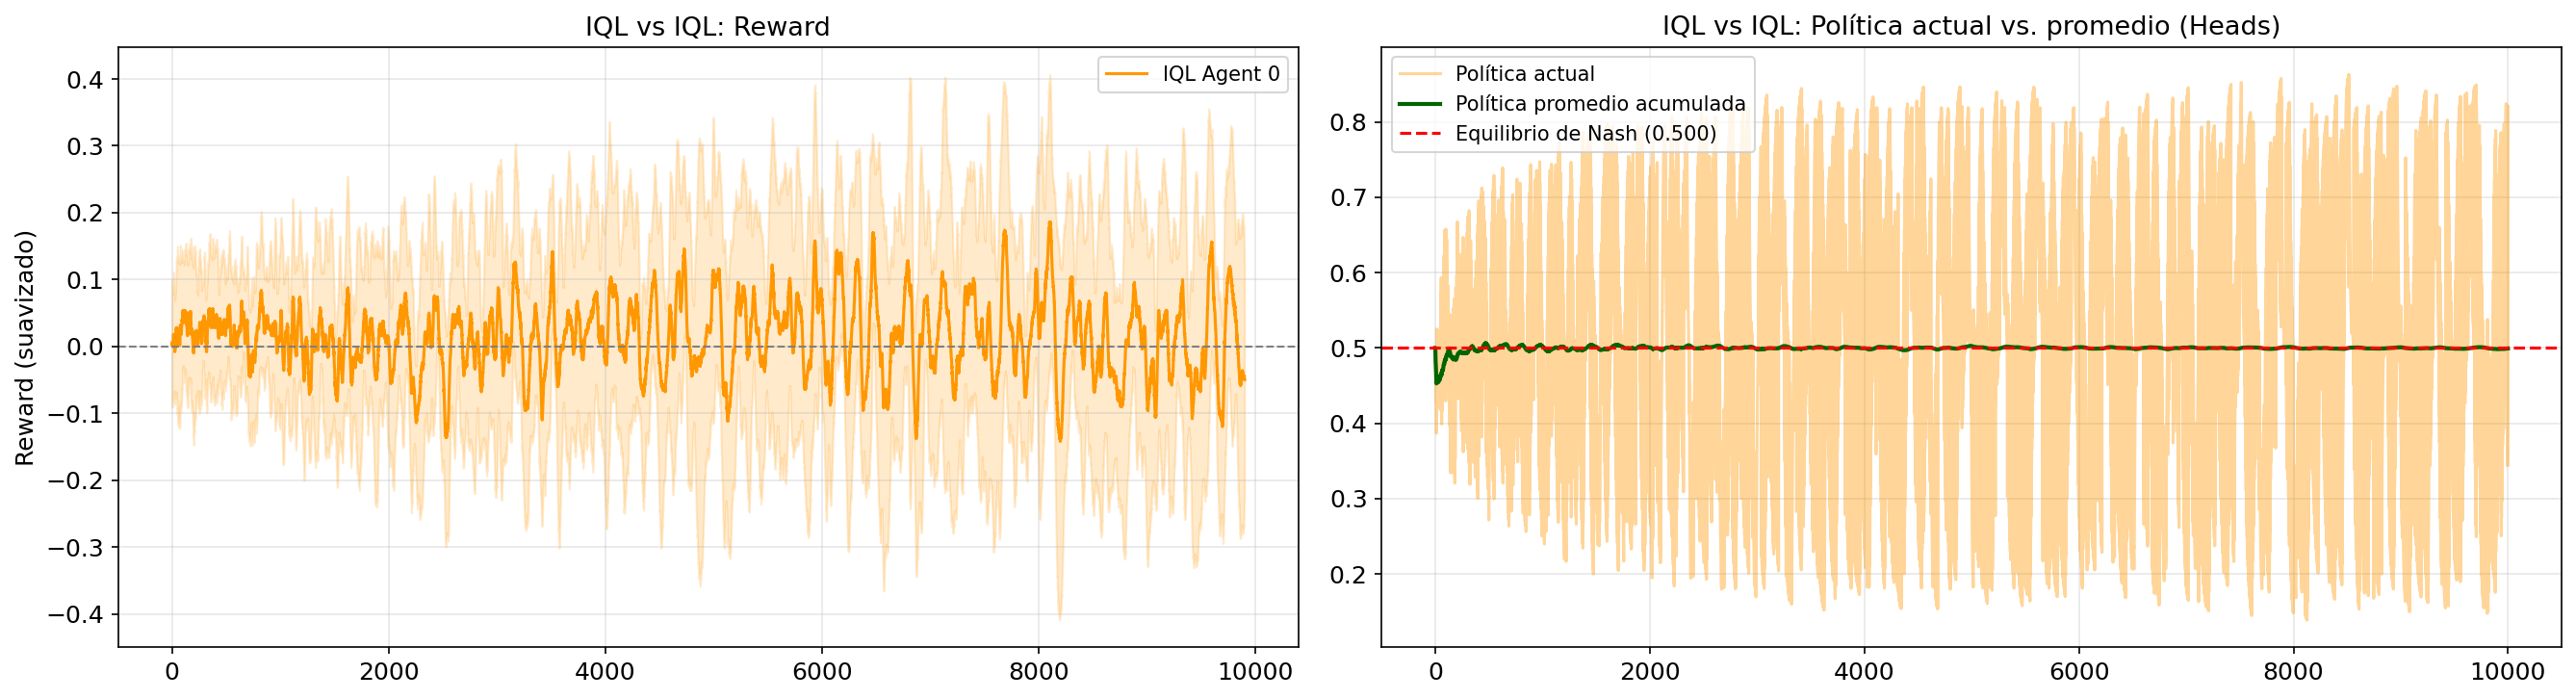

Política final FP (promedio sobre seeds):
  Agent 0: [0.509 0.491]
  Agent 1: [0.508 0.492]
  Equilibrio de Nash: [0.5 0.5]


In [35]:

rewards_iql, pol0_iql, pol1_iql = run_experiment_and_plot(
    MP, IndependentQLearning, IndependentQLearning,
    NE=NE_MP, color=COLORS['IQL'],
    game_name='MP', experiment_name='IQL_vs_IQL',
    agent0_label='IQL', agent1_label='IQL',
    action_label='Heads', action_idx=0,
    n_episodes=N_EPISODES, n_seeds=N_SEEDS,
    agent0_kwargs=IQL_KWARGS, agent1_kwargs=IQL_KWARGS,
)


#### JAL-AM vs JAL-AM

Saved → results/MP/JALAM_vs_JALAM/results.json


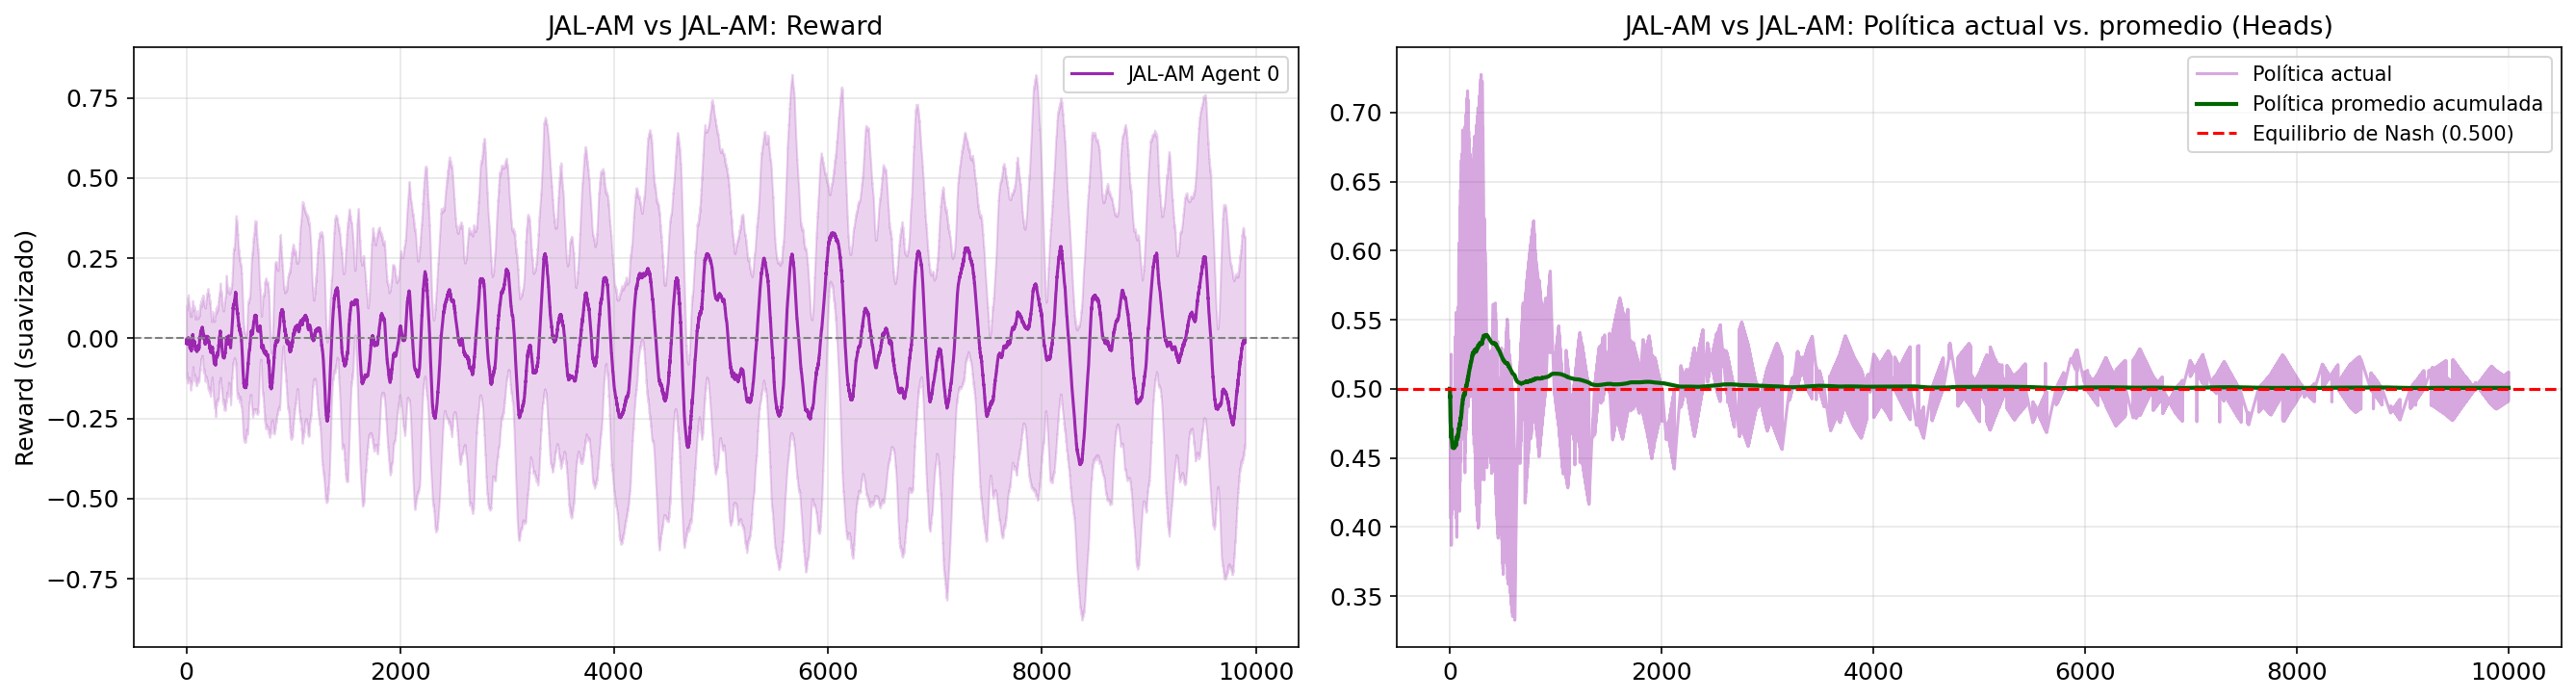

Política final FP (promedio sobre seeds):
  Agent 0: [0.5 0.5]
  Agent 1: [0.5 0.5]
  Equilibrio de Nash: [0.5 0.5]


In [36]:

rewards_jal, pol0_jal, pol1_jal = run_experiment_and_plot(
    MP, JointActionLearningAM, JointActionLearningAM,
    NE=NE_MP, color=COLORS['JAL-AM'],
    game_name='MP', experiment_name='JALAM_vs_JALAM',
    agent0_label='JAL-AM', agent1_label='JAL-AM',
    action_label='Heads', action_idx=0,
    n_episodes=N_EPISODES, n_seeds=N_SEEDS,
    agent0_kwargs=JALAM_KWARGS, agent1_kwargs=JALAM_KWARGS,
)


#### FP vs RM

Saved → results/MP/FP_vs_RM/results.json


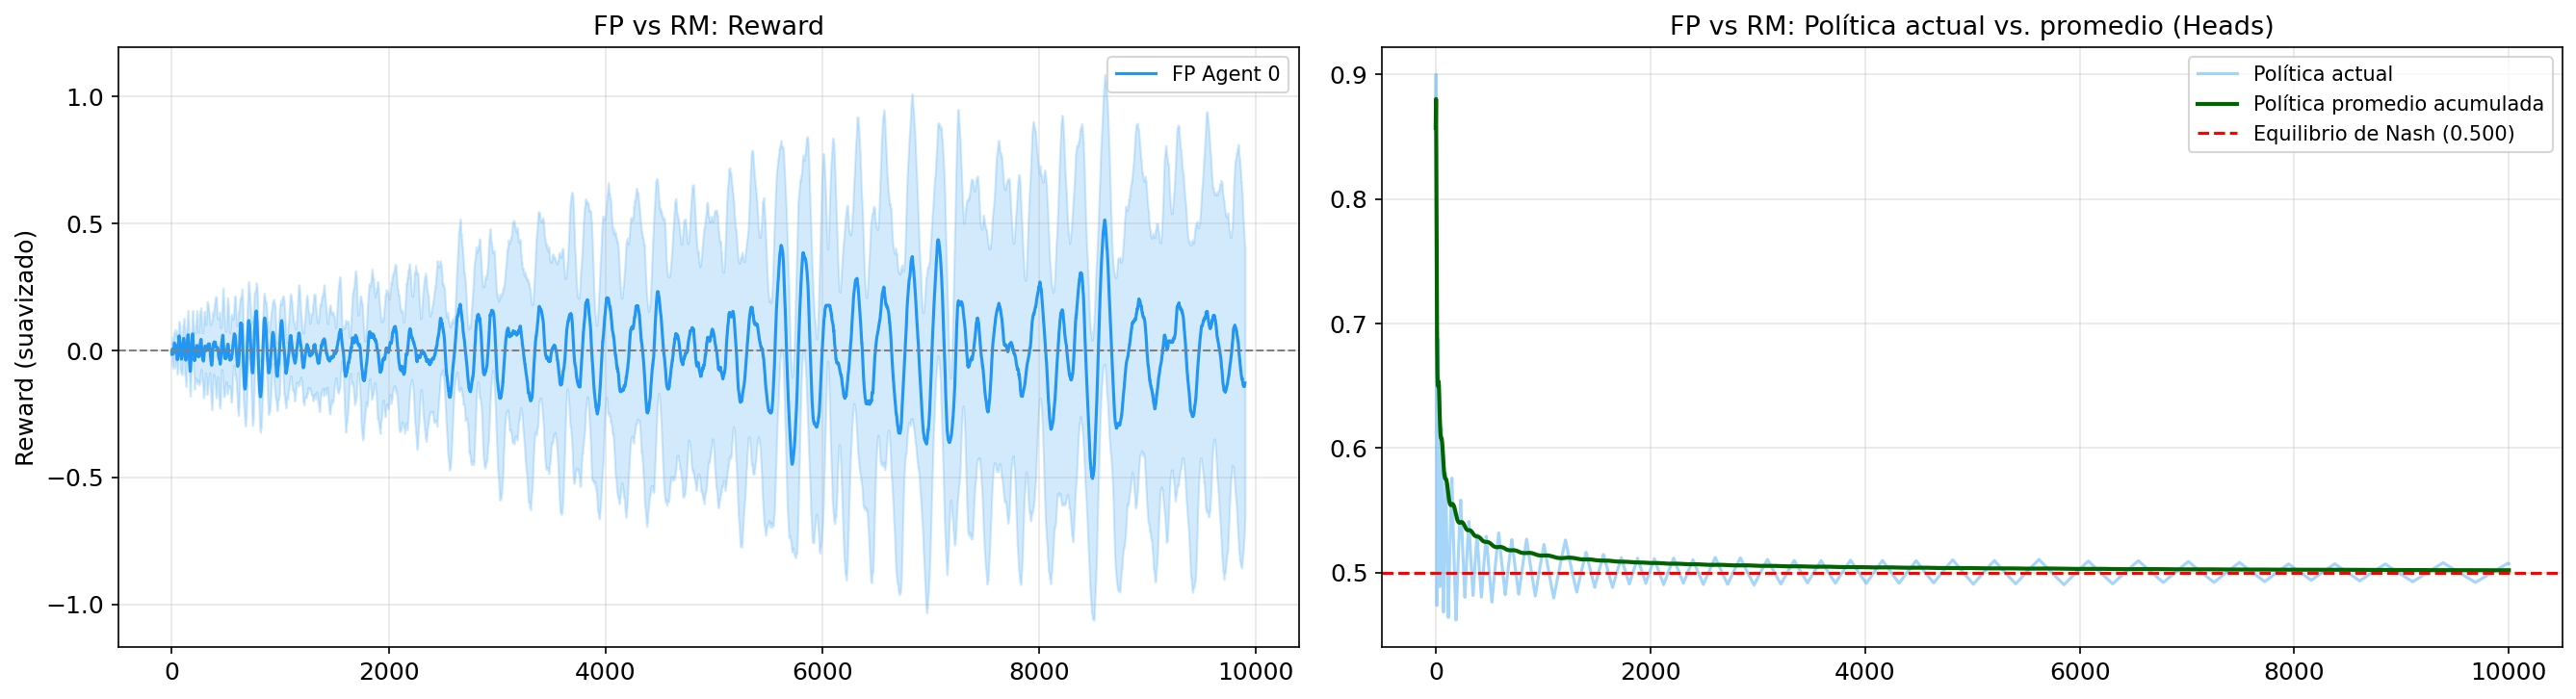

Política final FP (promedio sobre seeds):
  Agent 0: [0.5 0.5]
  Agent 1: [0.5 0.5]
  Equilibrio de Nash: [0.5 0.5]


In [37]:

rewards_fp_rm, pol0_fp_rm, pol1_fp_rm = run_experiment_and_plot(
    MP, FictitiousPlay, RegretMatching,
    NE=NE_MP, color=COLORS['FP'], color1=COLORS['RM'],
    game_name='MP', experiment_name='FP_vs_RM',
    agent0_label='FP', agent1_label='RM',
    action_label='Heads', action_idx=0,
    n_episodes=N_EPISODES, n_seeds=N_SEEDS,
)


#### Todos vs Random

Saved → results/MP/RM_vs_Random/results.json
Saved → results/MP/FP_vs_Random/results.json
Saved → results/MP/IQL_vs_Random/results.json
Saved → results/MP/JALAM_vs_Random/results.json


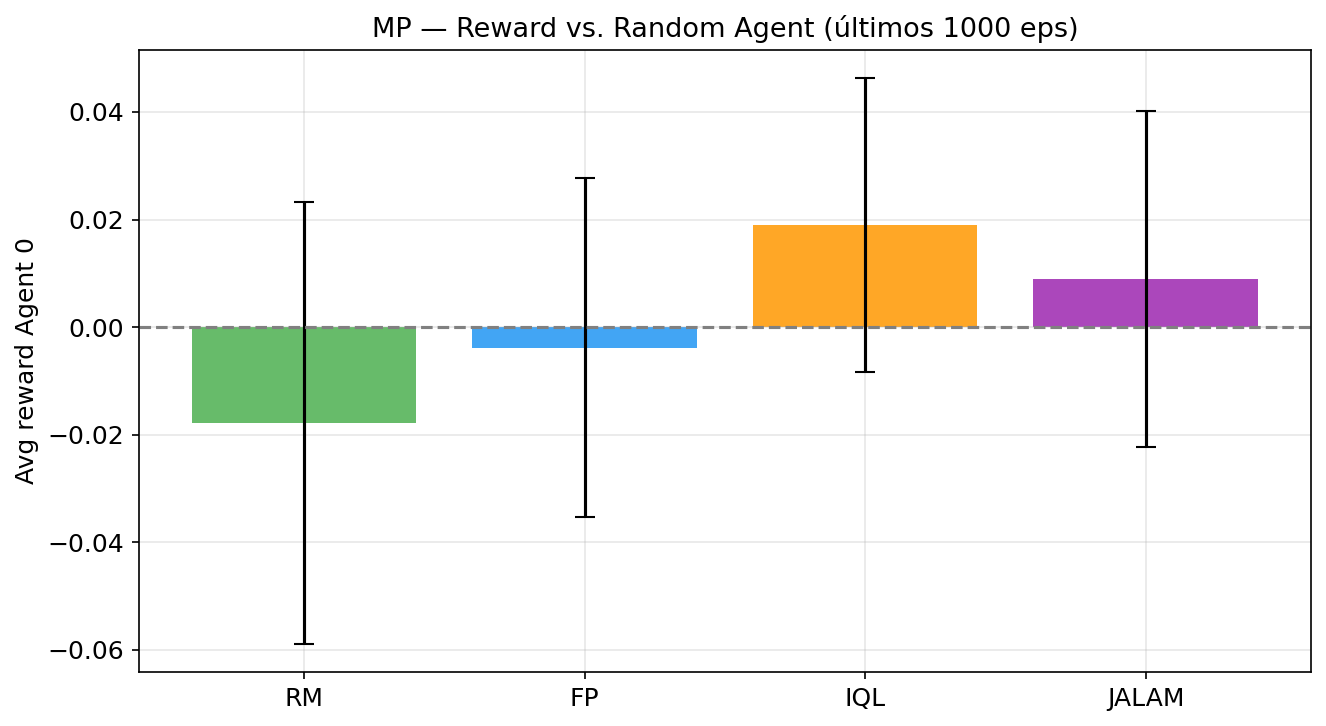

In [38]:

matchups_random = {
    'RM_vs_Random':    (RegretMatching,        RandomAgent, {}, {}),
    'FP_vs_Random':    (FictitiousPlay,        RandomAgent, {}, {}),
    'IQL_vs_Random':   (IndependentQLearning,  RandomAgent, IQL_KWARGS, {}),
    'JALAM_vs_Random': (JointActionLearningAM, RandomAgent, JALAM_KWARGS, {}),
}
vs_random_mp = {}
for name, (cls0, cls1, kw0, kw1) in matchups_random.items():
    r, p0, p1 = run_experiment(MP, cls0, cls1, N_EPISODES, N_SEEDS,
                               agent0_kwargs=kw0, agent1_kwargs=kw1)
    vs_random_mp[name] = (r, p0, p1)
    save_results('MP', name, r, p0, p1)

fig, ax = plt.subplots(figsize=(9, 5))
for i, (name, (r, _, _)) in enumerate(vs_random_mp.items()):
    mean_r = r[:, -1000:, 0].mean()
    std_r  = r[:, -1000:, 0].mean(axis=1).std()
    algo = name.split('_vs_')[0]
    ax.bar(i, mean_r, yerr=std_r, color=COLORS.get(algo, 'gray'),
           capsize=5, label=algo, alpha=0.85)
ax.set_xticks(range(len(matchups_random)))
ax.set_xticklabels([n.split('_vs_')[0] for n in matchups_random])
ax.set_title('MP — Reward vs. Random Agent (últimos 1000 eps)')
ax.set_ylabel('Avg reward Agent 0')
ax.axhline(0, ls='--', c='gray')
plt.tight_layout()
plt.savefig('figures/MP/vs_random_comparison.png', dpi=150)
plt.show()


#### Cross-play: Win Rate Matrix

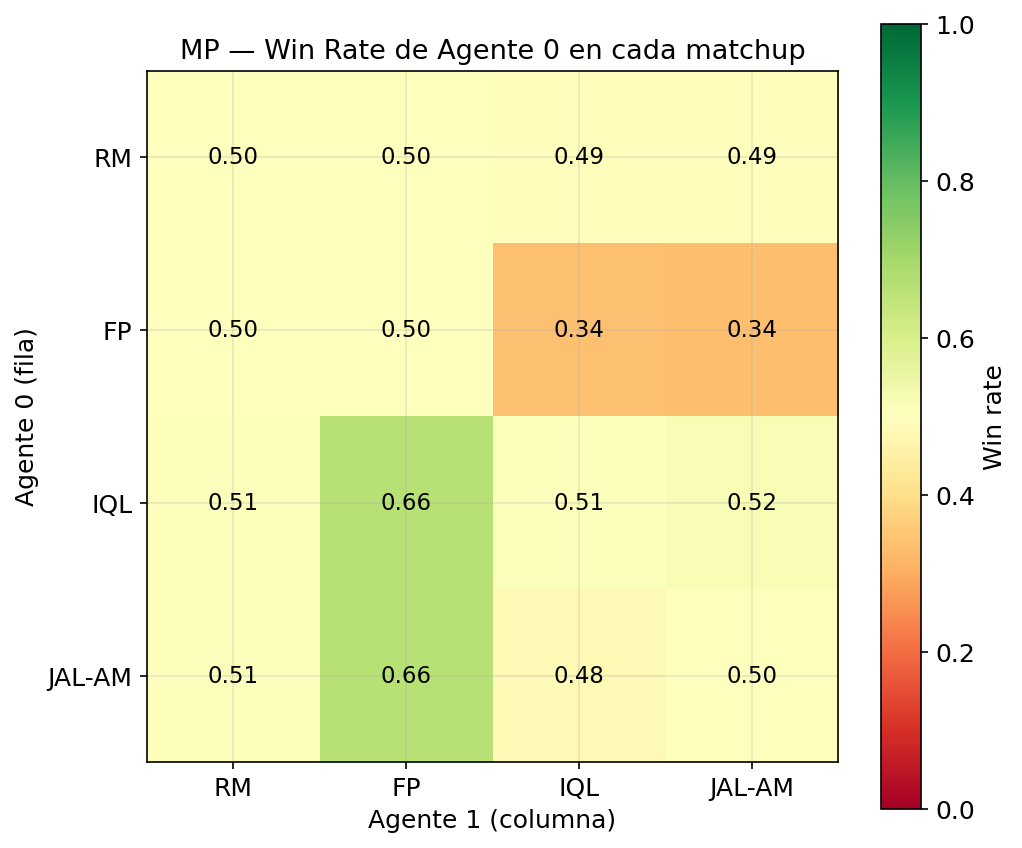

In [39]:

algo_classes_mp = {
    'RM':     (RegretMatching,        {}),
    'FP':     (FictitiousPlay,        {}),
    'IQL':    (IndependentQLearning,  IQL_KWARGS),
    'JAL-AM': (JointActionLearningAM, JALAM_KWARGS),
}
algos_mp = list(algo_classes_mp.keys())
win_rate_mp = np.zeros((len(algos_mp), len(algos_mp)))

for i, a0 in enumerate(algos_mp):
    for j, a1 in enumerate(algos_mp):
        cls0, kw0 = algo_classes_mp[a0]
        cls1, kw1 = algo_classes_mp[a1]
        r, _, _ = run_experiment(MP, cls0, cls1, N_EPISODES, N_SEEDS,
                                 agent0_kwargs=kw0, agent1_kwargs=kw1)
        win_rate_mp[i, j] = (r[:, :, 0] > 0).mean()

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(win_rate_mp, cmap='RdYlGn', vmin=0, vmax=1)
ax.set_xticks(range(len(algos_mp))); ax.set_yticks(range(len(algos_mp)))
ax.set_xticklabels(algos_mp); ax.set_yticklabels(algos_mp)
ax.set_xlabel('Agente 1 (columna)'); ax.set_ylabel('Agente 0 (fila)')
ax.set_title('MP — Win Rate de Agente 0 en cada matchup')
plt.colorbar(im, ax=ax, label='Win rate')
for i in range(len(algos_mp)):
    for j in range(len(algos_mp)):
        ax.text(j, i, f'{win_rate_mp[i,j]:.2f}', ha='center', va='center', fontsize=11)
plt.tight_layout()
plt.savefig('figures/MP/win_rate_matrix.png', dpi=150)
plt.show()


#### Comparación final: todos los algoritmos

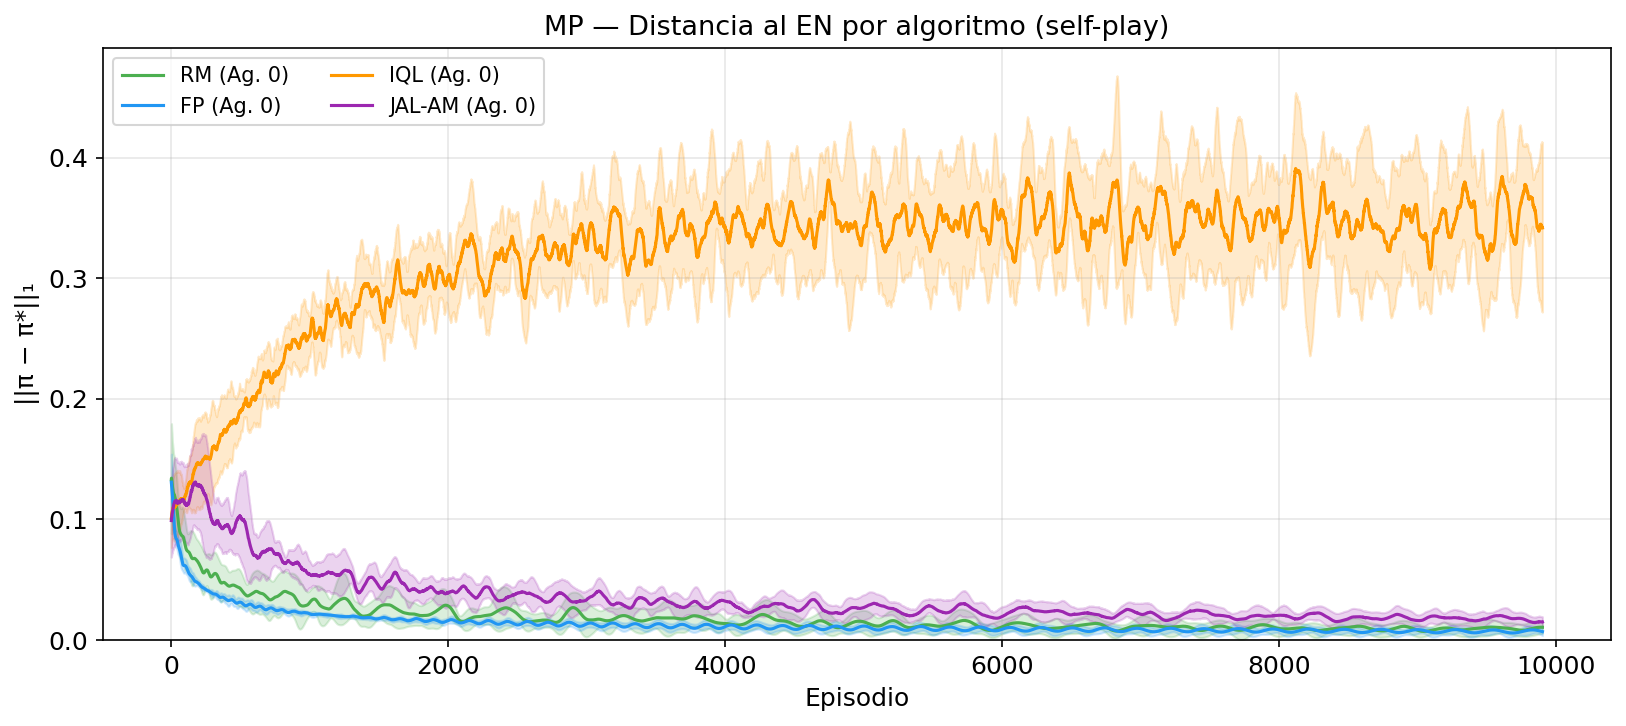


=== TABLA RESUMEN MATCHING PENNIES ===
Matchup                     Pol. final A0    Pol. final A1   Dist EN A0   Dist EN A1
-------------------------------------------------------------------------------------
RM vs RM                    [0.495 0.505]    [0.501 0.499]       0.0106       0.0078
FP vs FP                    [0.501 0.499]        [0.5 0.5]       0.0070       0.0072
IQL vs IQL                  [0.509 0.491]    [0.508 0.492]       0.3418       0.3568
JAL-AM vs JAL-AM                [0.5 0.5]        [0.5 0.5]       0.0150       0.0189
FP vs RM                        [0.5 0.5]        [0.5 0.5]       0.0076       0.0059


In [40]:

# Comparación visual: distancia al EN de todos los algoritmos (self-play)
fig, ax = plt.subplots(figsize=(11, 5))
algo_data_mp = [
    (pol0_rm,  'RM',     COLORS['RM']),
    (pol0_fp,  'FP',     COLORS['FP']),
    (pol0_iql, 'IQL',    COLORS['IQL']),
    (pol0_jal, 'JAL-AM', COLORS['JAL-AM']),
]
for pol0, name, color in algo_data_mp:
    plot_with_ci(dist_to_ne(pol0, NE_MP), f'{name} (Ag. 0)', color, ax=ax)

ax.set_xlabel('Episodio')
ax.set_ylabel('||π − π*||₁')
ax.set_title('MP — Distancia al EN por algoritmo (self-play)')
ax.legend(ncol=2)
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.savefig('figures/MP/all_algos_distance_ne.png', dpi=150)
plt.show()

# Tabla resumen
print("\n=== TABLA RESUMEN MATCHING PENNIES ===")
print(f"{'Matchup':<24} {'Pol. final A0':>16} {'Pol. final A1':>16} {'Dist EN A0':>12} {'Dist EN A1':>12}")
print("-" * 85)
datasets_mp = [
    (pol0_rm,    pol1_rm,    'RM vs RM'),
    (pol0_fp,    pol1_fp,    'FP vs FP'),
    (pol0_iql,   pol1_iql,   'IQL vs IQL'),
    (pol0_jal,   pol1_jal,   'JAL-AM vs JAL-AM'),
    (pol0_fp_rm, pol1_fp_rm, 'FP vs RM'),
]
for p0, p1, name in datasets_mp:
    pf0 = p0[:, -100:, :].mean(axis=(0, 1))
    pf1 = p1[:, -100:, :].mean(axis=(0, 1))
    d0  = dist_to_ne(p0, NE_MP)[:, -100:].mean(axis=1).mean()
    d1  = dist_to_ne(p1, NE_MP)[:, -100:].mean(axis=1).mean()
    print(f"{name:<24} {str(pf0.round(3)):>16} {str(pf1.round(3)):>16} {d0:>12.4f} {d1:>12.4f}")


## Conclusiones
- Como dijimos anteriormente, en Matching Pennies no hay estrategias dominantes puras(se desprende de la matriz de utilidades en la parte superior) y el equilibrio de Nash ocurre en estrategias mixtas(sorteando H y T con probabilidad *0.5*)
- De acuerdo con la performance obervada por cada agente en las partidas jugadas, podemos concluir comentando por cada agente:
    - **Random**: juega 50/50 y coincide con el equilibrio mixto, pero no aprende.
    - **IQL**: Fue el más inestable de todos, puede quedar sesgado al $\epsilon$ greedy en un problema que en principio no es estacionario.
    - **Ficticious Play**: En base a los experimentos, ha aproximado bien el equilibrio, es quizás el que mejor performó.
    - **Regret Matching**: Performó similar a Ficticious Play, aunque se desbió al final vs Random Agent, pero en promedio no estuvo tan lejos del equilibrio.
    - **JAL-AM**: Performa bastante mejor que IQL, ya que modela sus acciones y las del oponentes, aunque presentó mayores oscilaciones que Ficticious Play y Regret Matching.